In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import matplotlib.gridspec as gridspec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
from pathlib import Path



In [21]:
df = pd.read_parquet('../data/silver/emails_silver.parquet')

In [3]:
df.head()

,label,text,ingestion_timestamp,source_file,cleaned_text,processed_text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...,2026-05-02 09:49:12.354938,spam_Emails_data.csv,viiiiiiagraaaa only for the ones that want to ...,viiiiiiagraaaa one want make scream prodigy sc...
1,Ham,got ice thought look az original message ice o...,2026-05-02 09:49:12.354938,spam_Emails_data.csv,got ice thought look az original message ice o...,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...,2026-05-02 09:49:12.354938,spam_Emails_data.csv,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne ed escapenumber ch n b e th n f h...
3,Spam,start increasing your odds of success & live s...,2026-05-02 09:49:12.354938,spam_Emails_data.csv,start increasing your odds of success live sex...,start increasing odds success live sexually he...
4,Ham,author jra date escapenumber escapenumber esca...,2026-05-02 09:49:12.354938,spam_Emails_data.csv,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193848 entries, 0 to 193847
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   label                193848 non-null  object        
 1   text                 193848 non-null  object        
 2   ingestion_timestamp  193848 non-null  datetime64[us]
 3   source_file          193848 non-null  object        
 4   cleaned_text         193848 non-null  object        
 5   processed_text       193848 non-null  object        
dtypes: datetime64[us](1), object(5)
memory usage: 8.9+ MB


In [5]:
df.duplicated(subset=['text']).sum()

np.int64(0)

### Kiểm tra phân phối nhãn

In [6]:
df['label'].value_counts(normalize=True)

label
Ham     0.526995
Spam    0.473005
Name: proportion, dtype: float64

<Axes: xlabel='label', ylabel='count'>

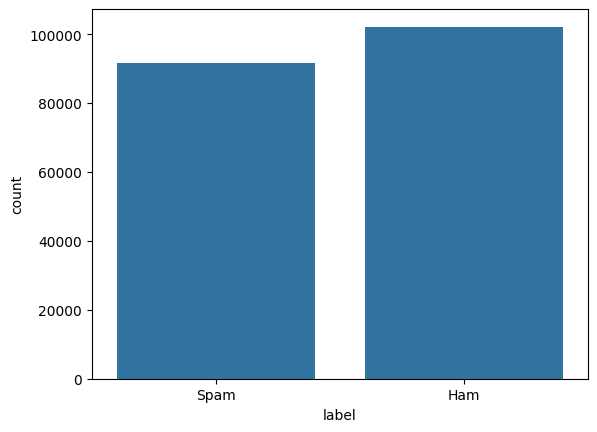

In [7]:
sns.countplot(x='label', data=df)

Nhãn tương đối cân bằng, không cần xử lý thêm

### Word Frequency Analysis

In [8]:
spam = df[df['label'] == 'Spam']['processed_text'].dropna()
ham  = df[df['label'] == 'Ham']['processed_text'].dropna()

def get_word_freq(series, top_n=20):
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(top_n)

In [9]:
def get_exclusive_words(spam_series, ham_series, top_n=500):
    spam_words   = ' '.join(spam_series).split()
    ham_words    = ' '.join(ham_series).split()
    spam_counter = Counter(spam_words)
    ham_counter  = Counter(ham_words)
    spam_vocab   = set(w for w, _ in spam_counter.most_common(top_n))
    ham_vocab    = set(w for w, _ in ham_counter.most_common(top_n))
    spam_excl = sorted({w: spam_counter[w] for w in spam_vocab - ham_vocab}.items(),
                        key=lambda x: x[1], reverse=True)[:20]
    ham_excl  = sorted({w: ham_counter[w]  for w in ham_vocab  - spam_vocab}.items(),
                        key=lambda x: x[1], reverse=True)[:20]
    return spam_excl, ham_excl

spam_freq              = get_word_freq(spam)
ham_freq               = get_word_freq(ham)
spam_exclusive, ham_exclusive = get_exclusive_words(spam, ham)

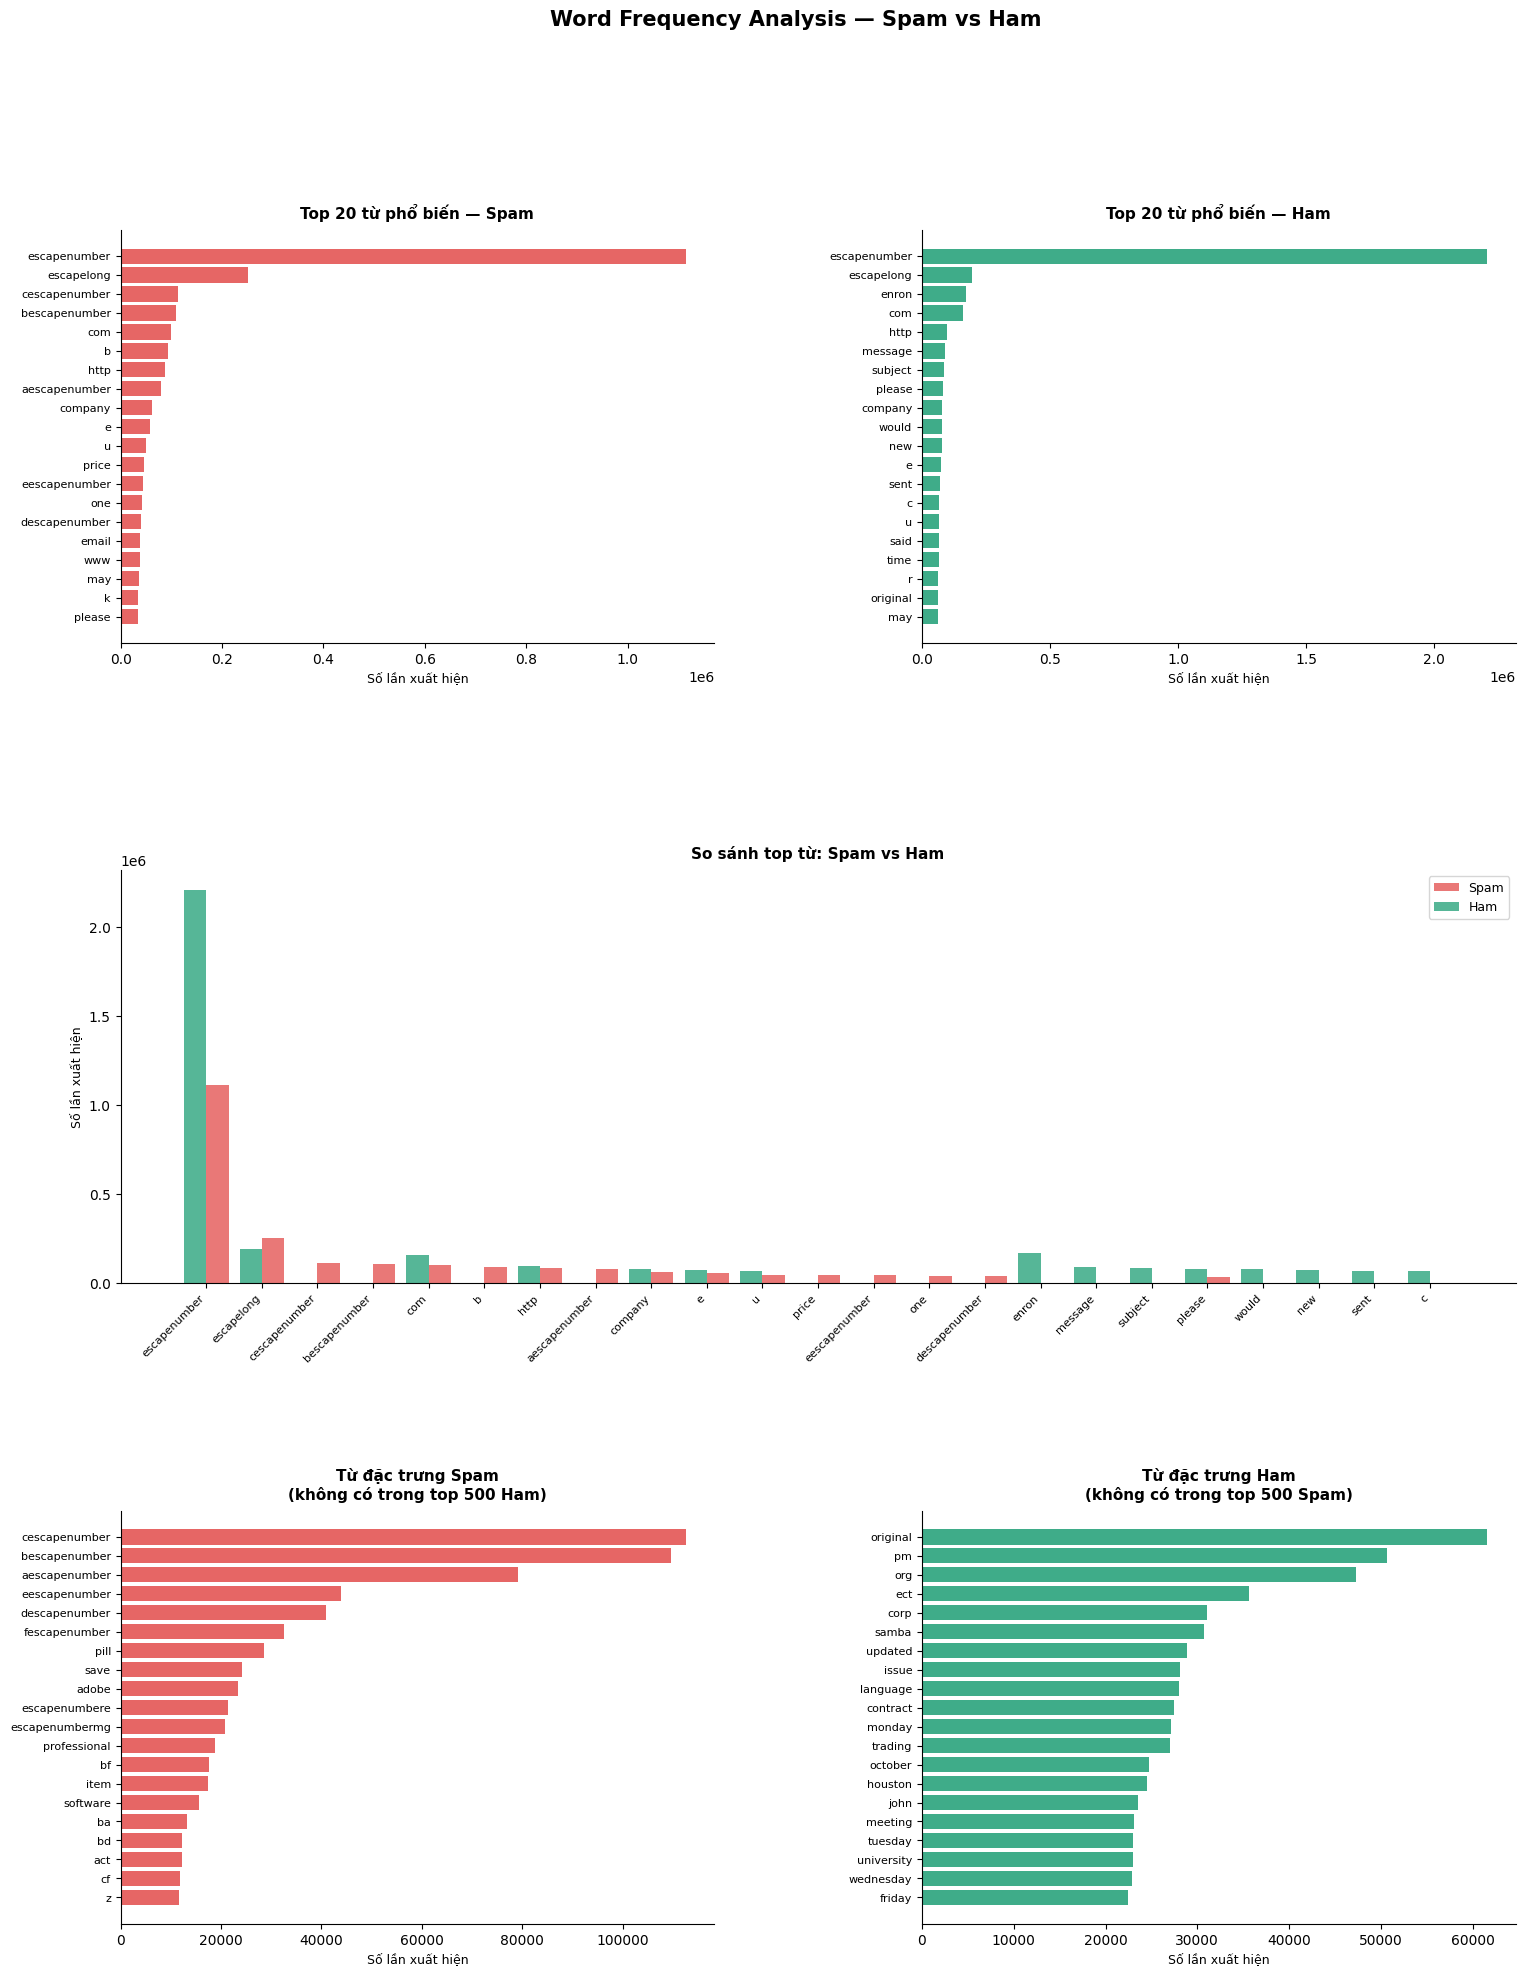

In [10]:
SPAM_COLOR = '#E24B4A'
HAM_COLOR  = '#1D9E75'

def plot_bar(ax, word_freq, title, color):
    words  = [w for w, _ in word_freq]
    counts = [c for _, c in word_freq]
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Số lần xuất hiện', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(18, 22))
fig.suptitle('Word Frequency Analysis — Spam vs Ham', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# Plot 1 & 2: Top 20 từ mỗi class
ax1 = fig.add_subplot(gs[0, 0])
plot_bar(ax1, spam_freq, 'Top 20 từ phổ biến — Spam', SPAM_COLOR)

ax2 = fig.add_subplot(gs[0, 1])
plot_bar(ax2, ham_freq,  'Top 20 từ phổ biến — Ham',  HAM_COLOR)

# Plot 3: So sánh side-by-side top 15 từ
ax3 = fig.add_subplot(gs[1, :])
spam_dict = dict(spam_freq)
ham_dict  = dict(ham_freq)
all_words = list(dict.fromkeys([w for w, _ in spam_freq[:15]] + [w for w, _ in ham_freq[:15]]))
x = range(len(all_words))
ax3.bar(x, [spam_dict.get(w, 0) for w in all_words],
        label='Spam', color=SPAM_COLOR, alpha=0.75, width=0.4, align='edge')
ax3.bar([i - 0.4 for i in x], [ham_dict.get(w, 0) for w in all_words],
        label='Ham',  color=HAM_COLOR,  alpha=0.75, width=0.4, align='edge')
ax3.set_xticks(list(x))
ax3.set_xticklabels(all_words, rotation=45, ha='right', fontsize=8)
ax3.set_title('So sánh top từ: Spam vs Ham', fontsize=11, fontweight='bold', pad=8)
ax3.set_ylabel('Số lần xuất hiện', fontsize=9)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Plot 4, 5: Từ đặc trưng exclusive
ax4 = fig.add_subplot(gs[2, 0])
plot_bar(ax4, spam_exclusive,
         'Từ đặc trưng Spam\n(không có trong top 500 Ham)', SPAM_COLOR)

ax5 = fig.add_subplot(gs[2, 1])
plot_bar(ax5, ham_exclusive,
         'Từ đặc trưng Ham\n(không có trong top 500 Spam)', HAM_COLOR)


plt.show()

In [11]:
# Thống kê tóm tắt
spam_vocab = set(' '.join(spam).split())
ham_vocab  = set(' '.join(ham).split())
print(f"Spam vocab size : {len(spam_vocab):>8,}")
print(f"Ham vocab size  : {len(ham_vocab):>8,}")
print(f"Shared vocab    : {len(spam_vocab & ham_vocab):>8,}")
print(f"Spam exclusive  : {len(spam_vocab - ham_vocab):>8,}")
print(f"Ham exclusive   : {len(ham_vocab - spam_vocab):>8,}")

print("\nTop 10 từ đặc trưng Spam:")
for word, count in spam_exclusive[:10]:
    print(f"  {word:<20} {count:>6,}")

print("\nTop 10 từ đặc trưng Ham:")
for word, count in ham_exclusive[:10]:
    print(f"  {word:<20} {count:>6,}")

Spam vocab size :  252,739
Ham vocab size  :  207,313
Shared vocab    :   66,082
Spam exclusive  :  186,657
Ham exclusive   :  141,231

Top 10 từ đặc trưng Spam:
  cescapenumber        112,614
  bescapenumber        109,666
  aescapenumber        79,076
  eescapenumber        43,871
  descapenumber        40,990
  fescapenumber        32,640
  pill                 28,530
  save                 24,224
  adobe                23,361
  escapenumbere        21,489

Top 10 từ đặc trưng Ham:
  original             61,601
  pm                   50,625
  org                  47,286
  ect                  35,628
  corp                 31,014
  samba                30,771
  updated              28,828
  issue                28,148
  language             28,014
  contract             27,439


#### Kết luận Word Frequency Analysis

**Tín hiệu tốt:** Từ vựng spam và ham có sự khác biệt rõ rệt
sau khi loại bỏ token escape và noise obfuscation.
TF-IDF có đủ signal để phân biệt 2 class.

**Cần xử lý trước khi build TF-IDF:**

1. Thêm vào custom stopwords:
   - Các ký tự đơn lẻ: `b`, `e`, `u`, `c`, `r`, `k`, `z` — noise

2. Cân nhắc loại bỏ biến thể obfuscation:
   - Pattern `[a-z]escapenumber` (`cescapenumber`, `bescapenumber`...): spam dùng ký tự đặc biệt để obfuscate từ ngữ.
   - Có thể dùng regex filter: `r'^[a-z]{1,2}escapenumber'`

3. Vocabulary spam đặc trưng có giá trị cao cho model:
   - `pill`, `save`, `adobe`, `software`, `item`, `professional`: đây là từ vựng marketing/lừa đảo điển hình

4. Vocabulary ham đặc trưng rõ ràng:
   - `original`, `pm`, `org`, `ect`, `corp`, `samba`,
     `meeting`, `contract`, `houston`, `university`: Hoàn toàn là từ vựng doanh nghiệp và kỹ thuật

Ngoài ra các từ `escapenumber`, `escapelong` xuất hiện khá đồng đều ở 2 nhãn, tiến hành thêm vào stopword để kiểm tra tần suất các từ khác tại wordcloud.

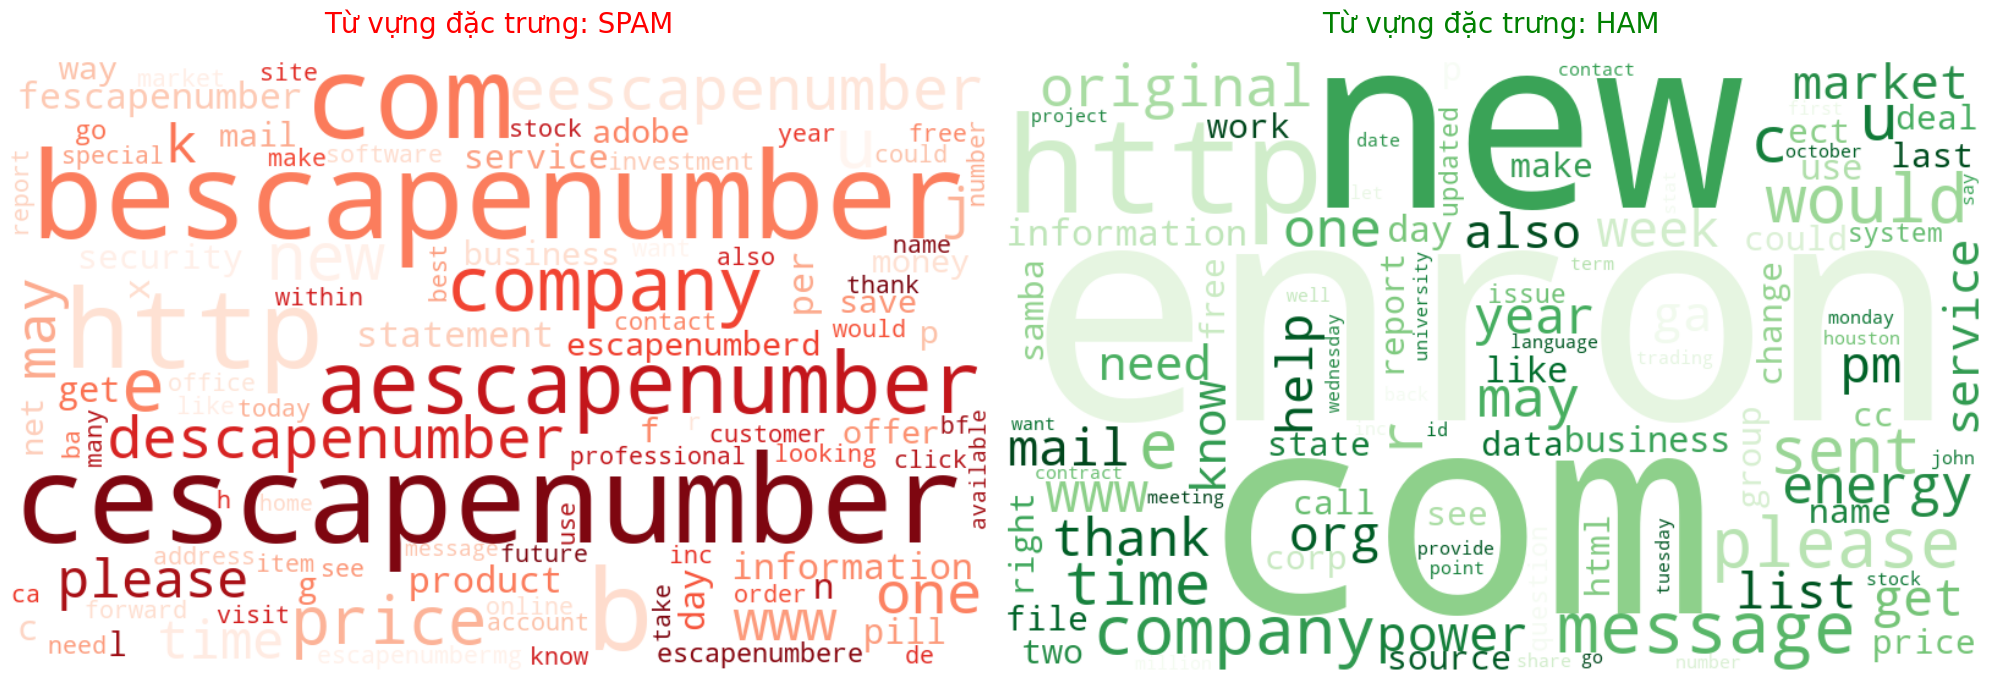

In [12]:
# Kiểm tra bằng wordcloud một lần nữa bằng cách custom thêm các stopwords không có giá trị phân loại
custom_stopwords = ['escapenumber', 'escapelong', 'subject', 'email', 'said']

def plot_word_clouds(df, text_col='processed_text', label_col='label'):
    # Tách văn bản của 2 nhãn
    spam_text = " ".join(df[df[label_col] == 'Spam'][text_col].astype(str))
    ham_text = " ".join(df[df[label_col] == 'Ham'][text_col].astype(str))

    # Cấu hình WordCloud
    # collocations=False để tránh lặp lại các cụm từ ghép
    wc_params = {
        'width': 800,
        'height': 500,
        'background_color': 'white',
        'max_words': 100,
        'stopwords': custom_stopwords,
        'collocations': False 
    }

    # Khởi tạo 2 đối tượng WordCloud
    wc_spam = WordCloud(**wc_params, colormap='Reds').generate(spam_text)
    wc_ham = WordCloud(**wc_params, colormap='Greens').generate(ham_text)

    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Cloud cho Spam
    axes[0].imshow(wc_spam, interpolation='bilinear')
    axes[0].set_title('Từ vựng đặc trưng: SPAM', fontsize=20, color='red', pad=20)
    axes[0].axis('off')

    # Cloud cho Ham
    axes[1].imshow(wc_ham, interpolation='bilinear')
    axes[1].set_title('Từ vựng đặc trưng: HAM', fontsize=20, color='green', pad=20)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


plot_word_clouds(df)

#### Kết luận từ Word Frequency Analysis và Word Cloud
1. Sự khác biệt rõ rệt về ngữ nghĩa (Semantic Signal)
    - Hai lớp dữ liệu có bộ từ vựng đặc trưng hoàn toàn khác nhau, đây là dấu hiệu cho thấy mô hình phân loại dựa trên văn bản (như Naive Bayes hoặc Logistic Regression với TF-IDF) sẽ đạt độ chính xác rất cao.

    - Cột SPAM (Màu đỏ): Tập trung vào các từ mang tính chất quảng cáo, giao dịch và lừa đảo. Các từ nổi bật bao gồm price (giá), money (tiền), pill (thuốc - đặc trưng của spam dược phẩm), software, adobe, save, offer.

    - Cột HAM (Màu xanh): Tập trung vào giao tiếp công việc và cá nhân. Từ nổi bật nhất là enron (xác nhận đây là bộ dữ liệu email của tập đoàn Enron nổi tiếng), cùng các từ như message, sent, business, meeting, original.

2. Đặc trưng dataset
    - Bộ dữ liệu gốc đã được xử lý để ẩn danh (masking) các con số. Tuy nhiên, các biến thể như bescapenumber xuất hiện cực kỳ nhiều ở nhóm Spam. Điều này cho thấy kẻ spam thường dùng nhiều con số (số tiền, số điện thoại, ngày tháng) và việc mô hình học được các token này sẽ giúp ích cho việc nhận diện thư rác.

3. Những từ "nhiễu" cần loại bỏ (Stopwords)
    - Có những từ xuất hiện lớn ở cả hai bên, điều này có nghĩa là chúng không có giá trị phân loại cao. Ví dụ: http, com, www, message, may, get.
    - Có thể đưa các từ này vào danh sách custom_stopwords ở tầng Gold để giảm chiều dữ liệu và giúp mô hình tập trung vào những từ thực sự có tính phân biệt (discriminative words).

### TF-IDF Baseline Model

Mục tiêu của bước này là chạy một model baseline đơn giản (Sử dụng Logistic Regression) để xác nhận `processed_text` có đủ signal trước khi vào gold layer

In [14]:
X = df['processed_text']
y = (df['label'] == 'Spam').astype(int)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        stop_words=None,   
        ngram_range=(1, 2) # Unigram + bigram
    )),
    ('clf', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipeline, X, y, cv=3, scoring='f1', n_jobs=-1)

print(f"F1 Score (5-fold CV): {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Scores từng fold    : {[f'{s:.4f}' for s in scores]}")

F1 Score (5-fold CV): 0.9739 ± 0.0008
Scores từng fold    : ['0.9751', '0.9731', '0.9736']


**Kết luận:** TF-IDF đủ mạnh, sẵn sàng để đưa vào gold layer